### Import librairies

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.special import ndtri

# Find the project root so this notebook also works when launched from a subfolder.
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "python_module" / "pricing_model.py").is_file():
        sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError("Could not find python_module/pricing_model.py from the notebook directory")

sns.set_theme()
# Show large numbers as 1_000_000; small ones (deltas, weights, prices) keep 4 significant digits
pd.set_option("display.float_format", lambda x: f"{x:_.0f}" if abs(x) >= 1_000 else f"{x:.4g}")

from python_module.pricing_model import BSMModel
from python_module.strike_reduction import (
    constrained_lasso, option_risk_table, quick_terminal_payoff_lasso, terminal_payoff_lasso,
)

### Custom functions

In [2]:
# Functions used across the notebook. They read notebook variables (portfolio, strikes, X, y, ...) defined in the
# sections below, so they can be defined here and called once those sections have run.

# --- Option portfolio ---
def log_contract(S):
    """Log contract 2/T * [(S - S_star) / S_star - ln(S / S_star)] replicated by the variance swap strip."""
    return 2 / T * ((S - S_star) / S_star - np.log(S / S_star))


def intrinsic_values(spots):
    """Unit payoff at expiry of each option for each spot: shape (n_spots, n_options)."""
    spots = np.asarray(spots)[:, None]
    return np.where(is_call, np.maximum(spots - strikes, 0.0), np.maximum(strikes - spots, 0.0))


# --- Reduced portfolios ---
def standard_lasso(X, y, risk, max_positions, **kwargs):
    """Classic lasso: constrained_lasso without the reweighting iterations (single pass, same penalty on every strike)."""
    return constrained_lasso(X, y, risk, max_positions, **standard_lasso_kwargs, **kwargs)


def r2(target, fitted):
    """Coefficient of determination of fitted vs target."""
    return 1 - ((target - fitted) ** 2).sum() / ((target - target.mean()) ** 2).sum()


def reduced_positions(result):
    """Selected options with their multiplier of the original quantity and the resulting reduced quantity."""
    reduced = portfolio.set_index("name").loc[result.weights.index, ["strike", "option_type", "quantity"]]
    reduced["multiplier"] = result.weights
    reduced["reduced_quantity"] = reduced["quantity"] * reduced["multiplier"]
    return reduced


def reduced_pnl(reduced):
    """Hedged P&L of a reduced portfolio on every path."""
    return X[reduced.index].to_numpy() @ reduced["multiplier"].to_numpy()


def pnl_r2(reduced):
    """R2 of a reduced portfolio on the delta hedged P&L across all paths (common yardstick across objectives)."""
    return r2(y, reduced_pnl(reduced))


def weights_by_name(result):
    """Re-index a strike-indexed result by option name, as used by the other sections of the notebook."""
    return result._replace(weights=result.weights.rename(index=portfolio.set_index("strike")["name"]))


# --- Plots ---
def grid_payoff(reduced):
    """Terminal payoff of a reduced portfolio on the Terminal Payoff spot grid."""
    return intrinsic_df[reduced.index].to_numpy() @ reduced["reduced_quantity"].to_numpy()


def gamma_surface_cash_mm(reduced):
    """Gamma cash (mm) of a reduced portfolio on the Gamma surface (spot x time)."""
    gamma_cash = X_gamma_surface[reduced.index].to_numpy() @ reduced["multiplier"].to_numpy()
    return gamma_cash.reshape(spot_grid.size, time_grid.size) / 1e6


def plot_strike_map(method_quantities):
    """Strike map of each method: y = strike, x = method, colour = sign of the quantity, dot area proportional to
    |quantity| (same size scale across methods so positions are directly comparable)."""
    dots = pd.concat(
        [q[q != 0].rename("quantity").reset_index().assign(method=m) for m, q in method_quantities.items()],
        ignore_index=True,
    )
    max_area = 600
    area_scale = max_area / dots["quantity"].abs().max()
    sign_colors = {True: "tab:green", False: "tab:red"}
    x_pos = {m: i for i, m in enumerate(method_quantities)}

    fig, ax = plt.subplots(figsize=(3 + 2 * len(x_pos), 8))
    ax.scatter(
        dots["method"].map(x_pos), dots["strike"],
        s=dots["quantity"].abs() * area_scale,
        c=(dots["quantity"] > 0).map(sign_colors),
        alpha=0.7, edgecolors="white", linewidths=0.5,
    )
    ax.axhline(S0, color="gray", linestyle="--", linewidth=1)

    # Legend: sign colours and reference sizes
    ref_sizes = [float(f"{q:.2g}") for q in np.array([0.1, 0.5, 1.0]) * dots["quantity"].abs().max()]
    handles = [plt.scatter([], [], s=60, color=sign_colors[True], label="Long"),
               plt.scatter([], [], s=60, color=sign_colors[False], label="Short")]
    handles += [plt.scatter([], [], s=q * area_scale, color="gray", alpha=0.5, label=f"{q:_.0f}") for q in ref_sizes]
    ax.legend(handles=handles, loc="center left", bbox_to_anchor=(1.02, 0.5), labelspacing=1.5, frameon=False, title="Quantity")

    ax.set_xticks(list(x_pos.values()), [m.replace(" (", "\n(") for m in x_pos])    # objective on its own line
    ax.set_xlim(-0.6, len(x_pos) - 0.4)
    ax.set_ylabel("Strike")
    ax.set_title("Option quantities by strike per method")
    plt.tight_layout()
    plt.show()


def plot_table(table_df, title):
    """Draws a DataFrame as a matplotlib table (hedged P&L R2 with 4 decimals, tracking error as an integer)."""
    formats = {"hedged_pnl_r2": "{:.4f}", "tracking_error_std": "{:_.0f}"}
    cell_text = [[formats.get(col, "{}").format(value) for col, value in row.items()] for _, row in table_df.iterrows()]

    fig, ax = plt.subplots(figsize=(2.2 * table_df.shape[1], 0.45 * (len(cell_text) + 2)))
    ax.axis("off")
    ax.set_title(title, weight="bold")
    table = ax.table(cellText=cell_text, colLabels=table_df.columns, loc="center", cellLoc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 1.6)
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("white")
        if row == 0:                                                          # header
            cell.set_facecolor(sns.color_palette()[0])
            cell.set_text_props(color="white", weight="bold")
        else:
            cell.set_facecolor("#eaeaf2" if row % 2 else "white")
    plt.tight_layout()
    plt.show()

### Inputs

In [3]:
# Pricing parameters
S0 = 100.0                                  # spot
T = 20 / 252                                # maturity (years)
r = 0.00                                    # risk-free rate
sigma = 0.20                                # volatility

# Monte Carlo parameters
n_paths = 10_000                            # MC paths (~0.1 MB per path at 20 steps x 100 options)
n_steps = max(1, round(T * 252))            # MC steps
seed = 42                                   # random seed
simulation_sigma = 0.20                     # volatility used for simulation

# Portfolio parameters
n_options = 200                             # number of options in the portfolio (keeps the strike spacing near 0.5)
# Delta bounds of the strike strip. They are far out (about 3.7 standard deviations each side) so the strip is wide
# enough to show the constant gamma cash region of the variance swap replication from inception
lower_bound_delta = -0.0001                 # lower delta strike to be included in the portfolio
upper_bound_delta = 0.0001                  # upper delta strike to be included in the portfolio
t0_gamma_cash = 50_000_000

# Strike reduction parameters
n_selected_options = 40                     # number of options kept by the reduction

# Standard lasso: single pass (no reweighting iteration). The risk constraints keep many strikes active at the usual
# top of the alpha grid, so the grid starts 100x higher (and is finer) to reach n_selected_options
standard_lasso_kwargs = {"n_iter": 1, "alpha_max": 100.0, "n_grid": 60}

# Risk constraints on (reduced - full portfolio) at t0
slide_shocks = [-0.05, -0.10]               # spot shocks of the delta hedged slides, each slide difference must be >= 0
vega_tolerance = 0.05                       # max relative vega difference vs the full portfolio

### Option portfolio creation

In [4]:
# Forward and strike bounds: closed-form inversion of the Black-76 delta
# call delta = disc * N(d1), put delta = disc * (N(d1) - 1), K = F * exp(-d1 * sigma * sqrt(T) + sigma^2 * T / 2)
F0 = BSMModel.compute_forward(S0, T, r, 0.0, 0.0)
discount = np.exp(-r * T)
d1_lower = ndtri(1 + lower_bound_delta / discount)
d1_upper = ndtri(upper_bound_delta / discount)
K_lower = F0 * np.exp(-d1_lower * sigma * np.sqrt(T) + 0.5 * sigma ** 2 * T)
K_upper = F0 * np.exp(-d1_upper * sigma * np.sqrt(T) + 0.5 * sigma ** 2 * T)

# Equally spaced strike grid; S_star is the node closest to the forward (put / call boundary)
strikes = np.linspace(K_lower, K_upper, n_options)
dK = strikes[1] - strikes[0]
S_star = strikes[np.argmin(np.abs(strikes - F0))]

# Variance swap replication (Demeterfi-Derman-Kamal-Zou): replicate the log contract
# f(S) = 2/T * [(S - S_star) / S_star - ln(S / S_star)] by its piecewise-linear interpolant on the strike nodes.
# The weight of each option is the slope change (kink) of the interpolant at its strike.
# One ghost node on each side lets the boundary strikes carry weight instead of being wasted.

nodes = np.concatenate([[K_lower - dK], strikes, [K_upper + dK]])
slopes = np.diff(log_contract(nodes)) / np.diff(nodes)
weights = np.diff(slopes)                                   # ~ 2 * dK / (T * K^2)

portfolio = pd.DataFrame({
    "strike": strikes,
    "option_type": np.where(strikes < S_star, "put", "call"),
    "weight": weights,
})
portfolio["delta"] = [
    BSMModel.compute_option_with_forward(F0, k, T, r, sigma, o, compute_greeks=True)["delta"]
    for k, o in zip(portfolio["strike"], portfolio["option_type"])
]
portfolio["price"] = [
    BSMModel.compute_option_with_forward(F0, k, T, r, sigma, o)
    for k, o in zip(portfolio["strike"], portfolio["option_type"])
]

# Scale the unit replication weights so the portfolio gamma cash (Gamma * S^2 / 100) at t0 and S0 equals t0_gamma_cash
unit_gamma = BSMModel.compute_option_with_forward(F0, strikes, T, r, sigma, "call", compute_greeks=True)["gamma"]
unit_gamma_cash = (weights * unit_gamma).sum() * np.exp(2 * r * T) * S0 ** 2 / 100
scale = t0_gamma_cash / unit_gamma_cash
portfolio["quantity"] = portfolio["weight"] * scale
portfolio["name"] = portfolio["option_type"] + "_" + portfolio["strike"].round(2).astype(str)

# Array views of the portfolio used by all the following sections
option_names = portfolio["name"].tolist()
is_call = (portfolio["option_type"] == "call").to_numpy()
quantities = portfolio["quantity"].to_numpy()
positions = portfolio.set_index("name")[["strike", "option_type", "quantity"]]

# Sanity check: fair variance implied by the replicating portfolio vs sigma^2.
# Holding only a call at S_star (instead of put + call) shifts the payoff by the linear term -slope_left * (S - S_star).
slope_left_star = slopes[np.searchsorted(nodes, S_star) - 1]
expected_log_contract = (portfolio["weight"] * portfolio["price"]).sum() / discount + slope_left_star * (F0 - S_star)
fair_variance = 2 / T * (r * T - (F0 / S_star - 1) - np.log(S_star / S0)) + expected_log_contract
print(f"Strike range: [{K_lower:.2f}, {K_upper:.2f}], dK = {dK:.4f}, S* = {S_star:.2f}")
print(f"Replicated fair vol: {np.sqrt(fair_variance):.4%} vs sigma: {sigma:.4%}")
print(f"Quantity scale: {scale:,.0f} (t0 gamma cash = {t0_gamma_cash:,.0f})")
display(portfolio)

Strike range: [81.22, 123.51], dK = 0.2125, S* = 99.92
Replicated fair vol: 20.0022% vs sigma: 20.0000%
Quantity scale: 198,449,732 (t0 gamma cash = 50,000,000)


,strike,option_type,weight,delta,price,quantity,name
0,81.22,put,0.0008116,-0.0001,0.0001367,161_062,put_81.22
1,81.44,put,0.0008074,-0.00012,0.0001657,160_223,put_81.44
2,81.65,put,0.0008032,-0.0001437,0.0002005,159_390,put_81.65
3,81.86,put,0.000799,-0.0001716,0.0002419,158_563,put_81.86
4,82.07,put,0.0007949,-0.0002045,0.0002913,157_744,put_82.07
...,...,...,...,...,...,...,...
195,122.7,call,0.0003559,0.0001613,0.0002206,70_628,call_122.66
196,122.9,call,0.0003547,0.0001433,0.0001947,70_384,call_122.87
197,123.1,call,0.0003534,0.0001272,0.0001717,70_141,call_123.08
198,123.3,call,0.0003522,0.0001128,0.0001513,69_900,call_123.29


### t0 risk metrics

In [5]:
# t0 risk of each option position (unit risk x quantity): delta, gamma cash, theta, vega and the delta hedged slides
# PV(S0 * (1 + x)) - PV(S0) - delta * S0 * x for each shock x in slide_shocks (see option_risk_table).
risk_positions = option_risk_table(positions, S0, T, r, sigma, slide_shocks)
slide_columns = [c for c in risk_positions.columns if c.startswith("slide_")]
full_risk = risk_positions.sum()
display(full_risk.to_frame("full portfolio"))

,full portfolio
delta,92_152
gamma_cash,50_000_000
theta,-396_825
vega,793_651
slide_-5%,6_464_369
slide_-10%,26_731_830


### Gamma surface

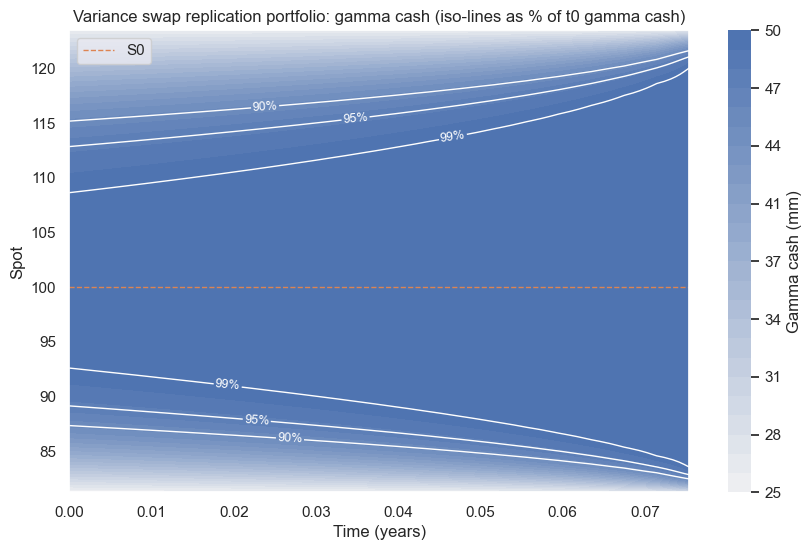

In [6]:
# Gamma cash (Gamma * S^2 / 100, P&L per 1% move squared) of each option position on a spot x time grid.
# The spot grid spans the strike range; the last time step is excluded since gamma is singular at expiry.
spot_grid = np.linspace(K_lower, K_upper, 200)
time_grid = np.linspace(0.0, T, n_steps + 1)[:-1]

gamma_cash_by_option = np.empty((spot_grid.size, time_grid.size, n_options))
for j, t in enumerate(time_grid):
    tau = T - t
    F_grid = spot_grid[:, None] * np.exp(r * tau)
    greeks = BSMModel.compute_option_with_forward(F_grid, strikes[None, :], tau, r, sigma, "call", compute_greeks=True)
    gamma_spot = greeks["gamma"] * np.exp(2 * r * tau)     # forward gamma -> spot gamma (same for calls and puts)
    gamma_cash_by_option[:, j] = gamma_spot * quantities * spot_grid[:, None] ** 2 / 100
gamma_cash = gamma_cash_by_option.sum(axis=2)

# Filled contours in millions, with labelled iso-lines at fractions of the t0 target to show where the replication holds
gamma_cash_mm = gamma_cash / 1e6
fill_levels = np.linspace(gamma_cash_mm.min(), gamma_cash_mm.max(), 25)
line_levels = t0_gamma_cash / 1e6 * np.array([0.90, 0.95, 0.99])

# Sequential colormap built from the seaborn theme palette (same blue as the terminal payoff plot)
theme_cmap = sns.light_palette(sns.color_palette()[0], as_cmap=True)

fig, ax = plt.subplots(figsize=(10, 6))
filled = ax.contourf(time_grid, spot_grid, gamma_cash_mm, levels=fill_levels, cmap=theme_cmap)
lines = ax.contour(time_grid, spot_grid, gamma_cash_mm, levels=line_levels, colors="white", linewidths=1)
ax.clabel(lines, fmt=lambda v: f"{v / (t0_gamma_cash / 1e6):.0%}", fontsize=9)
cbar = fig.colorbar(filled, ax=ax, format="%.0f")
cbar.set_label("Gamma cash (mm)")
cbar.outline.set_visible(False)
ax.axhline(S0, color=sns.color_palette()[1], linewidth=1, linestyle="--", label="S0")
ax.grid(False)
ax.set_xlabel("Time (years)")
ax.set_ylabel("Spot")
ax.set_title("Variance swap replication portfolio: gamma cash (iso-lines as % of t0 gamma cash)")
ax.legend(loc="upper left", frameon=True)
plt.show()

### Terminal Payoff

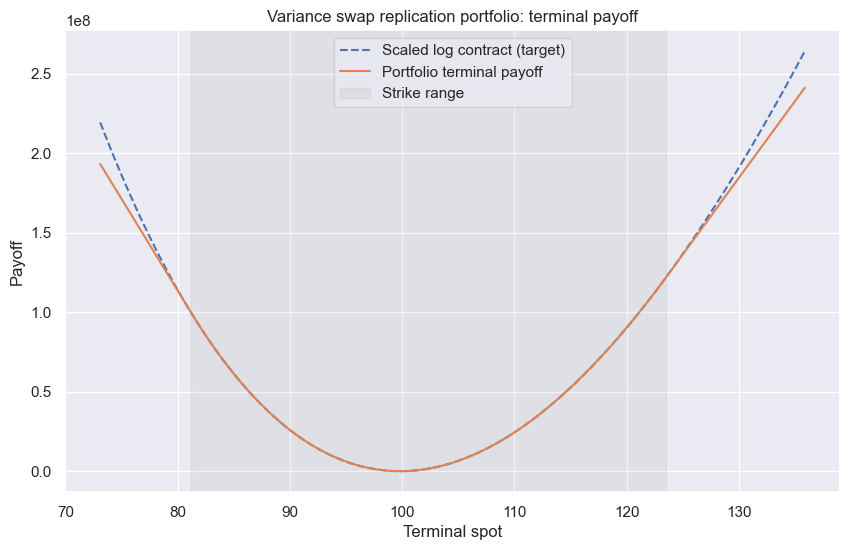

In [7]:
# Terminal payoff of the scaled portfolio vs the scaled log contract it replicates.
# The target includes the linear term from holding only a call at S_star: scale * [f(S) - slope_left * (S - S_star)].
terminal_spot = np.linspace(0.9 * K_lower, 1.1 * K_upper, 1_000)
intrinsic = intrinsic_values(terminal_spot)
terminal_payoff = intrinsic @ quantities
target_payoff = scale * (log_contract(terminal_spot) - slope_left_star * (terminal_spot - S_star))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(terminal_spot, target_payoff, linestyle="--", label="Scaled log contract (target)")
ax.plot(terminal_spot, terminal_payoff, label="Portfolio terminal payoff")
ax.axvspan(K_lower, K_upper, alpha=0.1, color="gray", label="Strike range")
ax.set_xlabel("Terminal spot")
ax.set_ylabel("Payoff")
ax.set_title("Variance swap replication portfolio: terminal payoff")
ax.legend(loc="upper center")
plt.show()

### Montecarlo simulation

In [8]:
# Simulate GBM spot paths with simulation_sigma; options are priced and delta hedged daily with the pricing sigma
spot_paths = BSMModel.compute_montecarlo(S0, T, r, 0.0, 0.0, simulation_sigma, n_steps, n_paths, seed=True, seed_value=seed).to_numpy().T
dt = T / n_steps
step_index = pd.RangeIndex(1, n_steps + 1, name="step")                    # step i is the P&L over day i (from step i-1 to i)
spot_step_index = pd.RangeIndex(0, n_steps + 1, name="step")               # spot fixings, step 0 is S0

# Option values and spot deltas on every path, step and strike: shape (n_paths, n_steps + 1, n_options)
values = np.empty((n_paths, n_steps + 1, n_options))
deltas = np.zeros((n_paths, n_steps + 1, n_options))
for j in range(n_steps + 1):
    tau = T - j * dt
    if j == n_steps:
        values[:, j] = intrinsic_values(spot_paths[:, j])
        continue
    F_j = spot_paths[:, j][:, None] * np.exp(r * tau)
    for option_type, mask in (("call", is_call), ("put", ~is_call)):
        res = BSMModel.compute_option_with_forward(F_j, strikes[mask], tau, r, sigma, option_type, compute_greeks=True)
        values[:, j, mask] = res["price"]
        deltas[:, j, mask] = res["delta"] * np.exp(r * tau)      # forward delta -> spot delta

# Daily position P&L (scaled by quantity). The hedge is short delta in spot, with the cash account financed at r.
dS = np.diff(spot_paths, axis=1)[:, :, None]
option_pnl = np.diff(values, axis=1) * quantities
delta_hedge_pnl = (-deltas[:, :-1] * dS + r * dt * (deltas[:, :-1] * spot_paths[:, :-1, None] - values[:, :-1])) * quantities
delta_hedged_option_pnl = option_pnl + delta_hedge_pnl
portfolio_pnl = delta_hedged_option_pnl.sum(axis=2)

# result_dict[path] -> {"option", "delta_hedge", "delta_hedged_option": DataFrame(step x option),
#                      "portfolio_delta_hedged": DataFrame(step x portfolio), "spot_timeseries": DataFrame(step x spot)}
result_dict = {
    path: {
        "option": pd.DataFrame(option_pnl[path], index=step_index, columns=option_names),
        "delta_hedge": pd.DataFrame(delta_hedge_pnl[path], index=step_index, columns=option_names),
        "delta_hedged_option": pd.DataFrame(delta_hedged_option_pnl[path], index=step_index, columns=option_names),
        "portfolio_delta_hedged": pd.DataFrame({"portfolio": portfolio_pnl[path]}, index=step_index),
        "spot_timeseries": pd.DataFrame({"spot": spot_paths[path]}, index=spot_step_index),
    }
    for path in range(n_paths)
}

# Sanity check: with simulation_sigma == sigma the delta hedged portfolio P&L should be centred on zero
total_portfolio_pnl = portfolio_pnl.sum(axis=1)
print(f"Portfolio premium: {(portfolio['quantity'] * portfolio['price']).sum():,.0f}")
print(f"Delta hedged portfolio total P&L: mean = {total_portfolio_pnl.mean():,.0f}, std = {total_portfolio_pnl.std():,.0f}")
# Per-path summary: annualised realised volatility (zero-mean, variance swap convention) and total hedged portfolio P&L
log_returns = np.diff(np.log(spot_paths), axis=1)
summary = pd.DataFrame(
    {
        "realized_volatility": np.sqrt((log_returns ** 2).sum(axis=1) / T),
        "portfolio_hedged_pnl": total_portfolio_pnl,
    },
    index=pd.RangeIndex(n_paths, name="path"),
)
display(summary.head())

Portfolio premium: 7,945,375
Delta hedged portfolio total P&L: mean = -1,356, std = 2,499,534


,realized_volatility,portfolio_hedged_pnl
path,,
0,0.1905,-751_896
1,0.1964,-296_537
2,0.1601,-2_856_529
3,0.2169,1_369_816
4,0.1348,-4_331_201


### P&L reduction

Portfolio P&L std = 2_499_659
Reweighting Lasso: 37 of 200 options, hedged P&L R2 = 0.9998, tracking error std = 31_822
Standard lasso: 38 of 200 options, hedged P&L R2 = 0.9152, tracking error std = 727_831


,strike,option_type,quantity,multiplier,reduced_quantity
put_83.99,83.99,put,150_642,12.74,1_918_702
put_86.11,86.11,put,143_300,8.41,1_205_139
put_87.39,87.39,put,139_149,4.669,649_744
put_88.45,88.45,put,135_826,5.511,748_514
put_89.51,89.51,put,132_621,3.879,514_438
put_90.36,90.36,put,130_138,5.38,700_184
put_91.64,91.64,put,126_542,5.761,729_026
put_92.27,92.27,put,124_800,0.79,98_594
put_92.91,92.91,put,123_093,4.718,580_697
put_93.76,93.76,put,120_872,3.701,447_366


,full,reduced,diff,ok
delta,92_152,135_619,43_467,NaN
gamma_cash,50_000_000,49_999_857,-143,True
theta,-396_825,-396_824,1.135,True
vega,793_651,793_649,-2.27,True
slide_-5%,6_464_369,6_468_364,3_995,True
slide_-10%,26_731_830,26_731_752,-78.03,True


,strike,option_type,quantity,multiplier,reduced_quantity
put_91.85,91.85,put,125_957,2.77,348_888
put_92.06,92.06,put,125_377,5.464,685_070
put_92.91,92.91,put,123_093,7.636,939_995
put_93.34,93.34,put,121_975,1.21,147_552
put_93.76,93.76,put,120_872,2.59,313_014
put_93.97,93.97,put,120_326,1.453,174_855
put_94.19,94.19,put,119_784,2.3,275_487
put_94.61,94.61,put,118_710,4.798,569_546
put_95.46,95.46,put,116_606,5.574,650_003
put_96.1,96.1,put,115_064,4.062,467_417


,full,reduced,diff,ok
delta,92_152,-319_018,-411_169,NaN
gamma_cash,50_000_000,49_999_967,-32.94,True
theta,-396_825,-396_825,0.2614,True
vega,793_651,793_650,-0.5229,True
slide_-5%,6_464_369,6_728_041,263_672,True
slide_-10%,26_731_830,26_731_813,-17.21,True


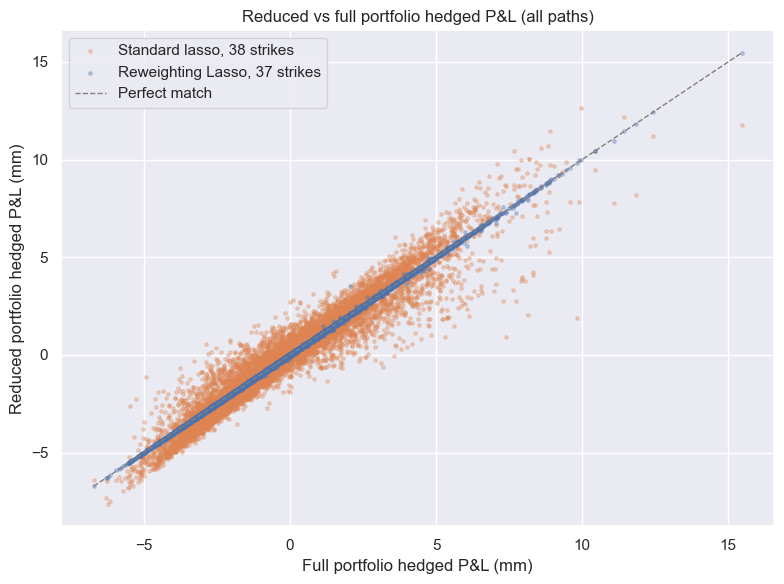

In [9]:
# Features: total delta hedged P&L of each option position per path (same as result_dict[path]["delta_hedged_option"].sum()).
# Target: total delta hedged portfolio P&L per path. Using quantity-scaled positions makes each coefficient a multiplier
# of the original quantity (the full portfolio is all ones). All paths are used: this is a theoretical fit, not a forecast.
X = pd.DataFrame(delta_hedged_option_pnl.sum(axis=1), index=summary.index, columns=option_names)
y = summary["portfolio_hedged_pnl"]

# t0 risk constraints on (reduced - full portfolio), passed to constrained_lasso for every objective
risk_constraints = {"floors": ["gamma_cash", "theta", *slide_columns], "bands": {"vega": vega_tolerance}}

pnl_lasso = constrained_lasso(X, y, risk_positions, n_selected_options, **risk_constraints)
reduced_pnl_portfolio = reduced_positions(pnl_lasso)
summary["reduced_hedged_pnl"] = reduced_pnl(reduced_pnl_portfolio)

# Standard lasso under the same risk constraints: single pass, no reweighting iterations (see standard_lasso)
pnl_standard = standard_lasso(X, y, risk_positions, n_selected_options, **risk_constraints)
reduced_pnl_standard_portfolio = reduced_positions(pnl_standard)
summary["standard_hedged_pnl"] = reduced_pnl(reduced_pnl_standard_portfolio)

print(f"Portfolio P&L std = {y.std():_.0f}")
for name, fit, col in (("Reweighting Lasso", pnl_lasso, "reduced_hedged_pnl"), ("Standard lasso", pnl_standard, "standard_hedged_pnl")):
    tracking_error = summary["portfolio_hedged_pnl"] - summary[col]
    print(f"{name}: {len(fit.weights)} of {n_options} options, hedged P&L R2 = {fit.r2:.4f}, "
          f"tracking error std = {tracking_error.std():_.0f}")
display(reduced_pnl_portfolio)
display(pnl_lasso.risk_check)
display(reduced_pnl_standard_portfolio)
display(pnl_standard.risk_check)

# Reduced vs full portfolio hedged P&L on every path
palette = sns.color_palette()
lims = np.array([y.min(), y.max()]) / 1e6

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y / 1e6, summary["standard_hedged_pnl"] / 1e6, s=6, alpha=0.3, color=palette[1], label=f"Standard lasso, {len(pnl_standard.weights)} strikes")
ax.scatter(y / 1e6, summary["reduced_hedged_pnl"] / 1e6, s=6, alpha=0.3, color=palette[0], label=f"Reweighting Lasso, {len(pnl_lasso.weights)} strikes")
ax.plot(lims, lims, color="gray", linestyle="--", linewidth=1, label="Perfect match")
ax.set_xlabel("Full portfolio hedged P&L (mm)")
ax.set_ylabel("Reduced portfolio hedged P&L (mm)")
ax.set_title("Reduced vs full portfolio hedged P&L (all paths)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [10]:
method_quantities = {
    "Full portfolio": portfolio.set_index("strike")["quantity"],
    "Reweighting Lasso (P&L)": reduced_pnl_portfolio.set_index("strike")["reduced_quantity"],
    "Standard lasso (P&L)": reduced_pnl_standard_portfolio.set_index("strike")["reduced_quantity"],
}

### Terminal payoff reduction

Reweighting Lasso: 17 of 200 options, terminal payoff R2 = 0.9997, hedged P&L R2 = 0.9958
Standard lasso: 37 of 200 options, terminal payoff R2 = 0.9660, hedged P&L R2 = 0.9230


,strike,option_type,quantity,multiplier,reduced_quantity
strike,,,,,
put_85.05,85.05,put,146_902,13.64,2_003_068
put_87.81,87.81,put,137_805,16.32,2_248_875
put_91.0,91,put,128_321,12.09,1_551_825
put_92.91,92.91,put,123_093,7.975,981_654
put_94.4,94.4,put,119_245,5.619,669_978
put_95.89,95.89,put,115_574,8.418,972_952
put_97.8,97.8,put,111_099,10.34,1_148_622
put_99.71,99.71,put,106_878,3.946,421_769
call_99.92,99.92,call,106_424,0.09188,9_778


,full,reduced,diff,ok
delta,92_152,91_943,-208.7,NaN
gamma_cash,50_000_000,49_999_967,-32.5,True
theta,-396_825,-396_825,0.258,True
vega,793_651,793_650,-0.5159,True
slide_-5%,6_464_369,6_473_060,8_691,True
slide_-10%,26_731_830,26_731_818,-12.08,True


,strike,option_type,quantity,multiplier,reduced_quantity
strike,,,,,
put_92.7,92.7,put,123_658,5.946,735_315
put_92.91,92.91,put,123_093,17.22,2_119_143
put_93.55,93.55,put,121_422,1.76,213_658
put_93.76,93.76,put,120_872,6.354e-05,7.681
put_93.97,93.97,put,120_326,4.264,513_089
put_94.4,94.4,put,119_245,4.473e-05,5.334
put_94.61,94.61,put,118_710,0.7199,85_461
put_94.82,94.82,put,118_179,0.0002913,34.42
put_95.04,95.04,put,117_651,3.418,402_138


,full,reduced,diff,ok
delta,92_152,95_193,3_041,NaN
gamma_cash,50_000_000,49_999_930,-70.03,True
theta,-396_825,-396_825,0.5558,True
vega,793_651,793_650,-1.112,True
slide_-5%,6_464_369,6_695_451,231_082,True
slide_-10%,26_731_830,26_731_787,-43.16,True


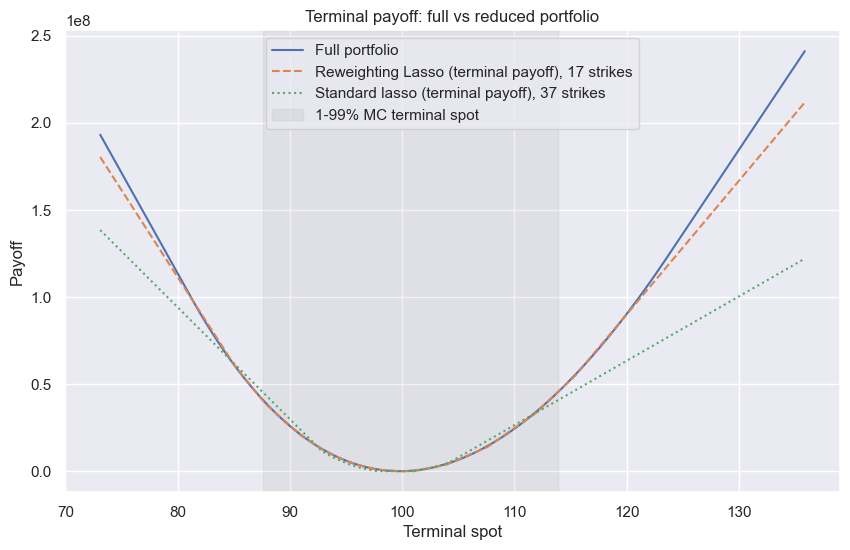

In [11]:
# Replicate the terminal payoff of the full portfolio under the t0 risk constraints. The payoffs are sampled at the
# Monte Carlo terminal spots, so strikes are weighted by how likely the spot ends there.
# Inputs are indexed by terminal spot level (rows) and option strike (columns / risk index).
terminal_spots = spot_paths[:, -1]
option_terminal_payoff = pd.DataFrame(
    intrinsic_values(terminal_spots) * quantities,
    index=pd.Index(terminal_spots, name="terminal_spot"), columns=pd.Index(strikes, name="strike"),
)
portfolio_terminal_payoff = option_terminal_payoff.sum(axis=1)
risk_by_strike = risk_positions.set_axis(option_terminal_payoff.columns)

payoff_lasso = weights_by_name(terminal_payoff_lasso(
    portfolio_terminal_payoff, option_terminal_payoff, n_selected_options,
    t0_risk=risk_by_strike, risk_floor=risk_constraints["floors"], risk_tolerance=risk_constraints["bands"],
))
reduced_payoff_portfolio = reduced_positions(payoff_lasso)
payoff_standard = weights_by_name(terminal_payoff_lasso(
    portfolio_terminal_payoff, option_terminal_payoff, n_selected_options,
    t0_risk=risk_by_strike, risk_floor=risk_constraints["floors"], risk_tolerance=risk_constraints["bands"], **standard_lasso_kwargs,
))
reduced_payoff_standard_portfolio = reduced_positions(payoff_standard)
for name, fit, reduced in (("Reweighting Lasso", payoff_lasso, reduced_payoff_portfolio), ("Standard lasso", payoff_standard, reduced_payoff_standard_portfolio)):
    print(f"{name}: {len(fit.weights)} of {n_options} options, terminal payoff R2 = {fit.r2:.4f}, "
          f"hedged P&L R2 = {pnl_r2(reduced):.4f}")
display(reduced_payoff_portfolio)
display(payoff_lasso.risk_check)
display(reduced_payoff_standard_portfolio)
display(payoff_standard.risk_check)

# Terminal payoff of the full vs reduced portfolio on the same spot grid as the Terminal Payoff section
intrinsic_df = pd.DataFrame(intrinsic, columns=option_names)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(terminal_spot, terminal_payoff, label="Full portfolio")
ax.plot(terminal_spot, grid_payoff(reduced_payoff_portfolio), linestyle="--", label=f"Reweighting Lasso (terminal payoff), {len(payoff_lasso.weights)} strikes")
ax.plot(terminal_spot, grid_payoff(reduced_payoff_standard_portfolio), linestyle=":", label=f"Standard lasso (terminal payoff), {len(payoff_standard.weights)} strikes")
ax.axvspan(*np.percentile(terminal_spots, [1, 99]), alpha=0.1, color="gray", label="1-99% MC terminal spot")
ax.set_xlabel("Terminal spot")
ax.set_ylabel("Payoff")
ax.set_title("Terminal payoff: full vs reduced portfolio")
ax.legend(loc="upper center")
plt.show()

method_quantities["Reweighting Lasso (terminal payoff)"] = reduced_payoff_portfolio.set_index("strike")["reduced_quantity"]
method_quantities["Standard lasso (terminal payoff)"] = reduced_payoff_standard_portfolio.set_index("strike")["reduced_quantity"]

### Gamma at inception reduction

Reweighting Lasso: 37 of 200 options, gamma_at_inception R2 = 0.9999, hedged P&L R2 = 0.8743
Standard lasso: 26 of 200 options, gamma_at_inception R2 = 0.9985, hedged P&L R2 = 0.8993


,strike,option_type,quantity,multiplier,reduced_quantity
put_83.99,83.99,put,150_642,9.513e-05,14.33
put_84.2,84.2,put,149_883,28.06,4_205_215
put_84.41,84.41,put,149_129,2.089,311_578
put_84.62,84.62,put,148_381,5.134e-05,7.618
put_90.79,90.79,put,128_923,4.894e-05,6.309
put_91.0,91,put,128_321,9.982e-05,12.81
put_91.21,91.21,put,127_724,0.000301,38.45
put_91.42,91.42,put,127_131,15.27,1_941_181
put_91.64,91.64,put,126_542,21.78,2_755_626
put_91.85,91.85,put,125_957,0.0002498,31.46


,full,reduced,diff,ok
delta,92_152,-315_727,-407_879,NaN
gamma_cash,50_000_000,49_999_624,-375.8,True
theta,-396_825,-396_822,2.983,True
vega,793_651,793_645,-5.965,True
slide_-5%,6_464_369,6_464_680,311.2,True
slide_-10%,26_731_830,26_731_631,-199.8,True


,strike,option_type,quantity,multiplier,reduced_quantity
put_84.41,84.41,put,149_129,7.502e-05,11.19
put_84.62,84.62,put,148_381,21.21,3_146_579
put_84.84,84.84,put,147_639,11.64,1_718_822
put_91.42,91.42,put,127_131,9.581e-05,12.18
put_91.64,91.64,put,126_542,0.0006886,87.14
put_91.85,91.85,put,125_957,3.429,431_914
put_92.06,92.06,put,125_377,30.53,3_827_707
put_92.27,92.27,put,124_800,0.0004164,51.96
put_92.49,92.49,put,124_227,6.834e-05,8.49
put_98.65,98.65,put,109_193,5.91e-05,6.453


,full,reduced,diff,ok
delta,92_152,-1_605_232,-1_697_384,NaN
gamma_cash,50_000_000,49_999_630,-370.2,True
theta,-396_825,-396_822,2.938,True
vega,793_651,793_645,-5.876,True
slide_-5%,6_464_369,6_468_984,4_616,True
slide_-10%,26_731_830,26_731_636,-194.9,True


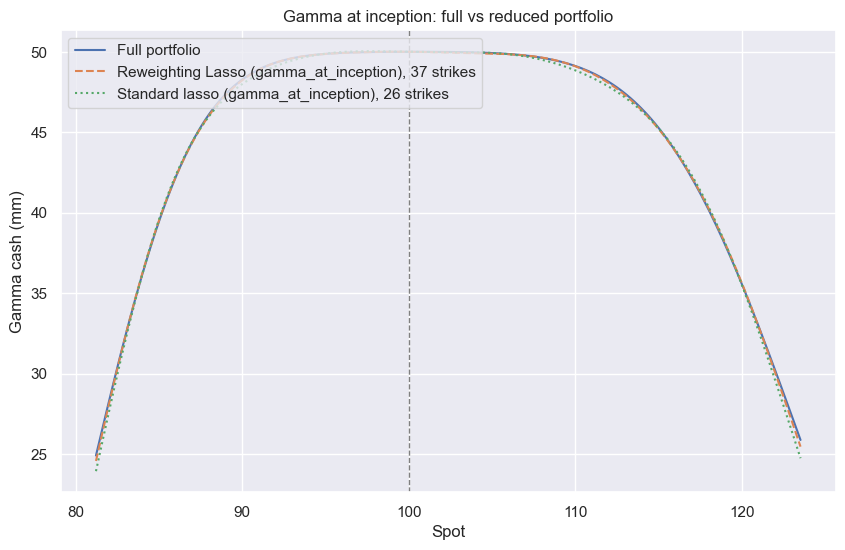

In [12]:
# Features: gamma cash of each option position on the Gamma surface spot axis at inception only (t = 0 slice);
# target: gamma cash at inception of the full portfolio. Every spot has the same weight.
X_gamma_at_inception = pd.DataFrame(gamma_cash_by_option[:, 0, :], index=pd.Index(spot_grid, name="spot"), columns=option_names)
y_gamma_at_inception = X_gamma_at_inception.sum(axis=1)

gamma_at_inception_lasso = constrained_lasso(X_gamma_at_inception, y_gamma_at_inception, risk_positions, n_selected_options, **risk_constraints)
reduced_gamma_at_inception_portfolio = reduced_positions(gamma_at_inception_lasso)
gamma_at_inception_standard = standard_lasso(X_gamma_at_inception, y_gamma_at_inception, risk_positions, n_selected_options, **risk_constraints)
reduced_gamma_at_inception_standard_portfolio = reduced_positions(gamma_at_inception_standard)
for name, fit, reduced in (("Reweighting Lasso", gamma_at_inception_lasso, reduced_gamma_at_inception_portfolio), ("Standard lasso", gamma_at_inception_standard, reduced_gamma_at_inception_standard_portfolio)):
    print(f"{name}: {len(fit.weights)} of {n_options} options, gamma_at_inception R2 = {fit.r2:.4f}, "
          f"hedged P&L R2 = {pnl_r2(reduced):.4f}")
display(reduced_gamma_at_inception_portfolio)
display(gamma_at_inception_lasso.risk_check)
display(reduced_gamma_at_inception_standard_portfolio)
display(gamma_at_inception_standard.risk_check)

# Gamma cash at inception across spot of the full vs reduced portfolio
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(spot_grid, y_gamma_at_inception / 1e6, label="Full portfolio")
for (label, fit, reduced), style in zip((("Reweighting Lasso", gamma_at_inception_lasso, reduced_gamma_at_inception_portfolio),
                                         ("Standard lasso", gamma_at_inception_standard, reduced_gamma_at_inception_standard_portfolio)), ("--", ":")):
    fitted = X_gamma_at_inception[reduced.index].to_numpy() @ reduced["multiplier"].to_numpy()
    ax.plot(spot_grid, fitted / 1e6, linestyle=style, label=f"{label} (gamma_at_inception), {len(fit.weights)} strikes")
ax.axvline(S0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Spot")
ax.set_ylabel("Gamma cash (mm)")
ax.set_title("Gamma at inception: full vs reduced portfolio")
ax.legend(loc="upper left")
plt.show()

method_quantities["Reweighting Lasso (gamma_at_inception)"] = reduced_gamma_at_inception_portfolio.set_index("strike")["reduced_quantity"]
method_quantities["Standard lasso (gamma_at_inception)"] = reduced_gamma_at_inception_standard_portfolio.set_index("strike")["reduced_quantity"]

### Gamma surface reduction

Reweighting Lasso: 28 of 200 options, gamma_surface R2 = 0.9991, hedged P&L R2 = 0.9984
Standard lasso: 28 of 200 options, gamma_surface R2 = -29.6266, hedged P&L R2 = 0.8065


,strike,option_type,quantity,multiplier,reduced_quantity
put_81.22,81.22,put,161_062,1.281,206_264
put_82.29,82.29,put,156_930,8.619,1_352_558
put_84.2,84.2,put,149_883,8.113,1_216_015
put_85.26,85.26,put,146_171,4.244,620_414
put_86.96,86.96,put,140_512,10.55,1_481_872
put_89.3,89.3,put,133_253,10.92,1_455_258
put_90.79,90.79,put,128_923,2.548,328_521
put_92.06,92.06,put,125_377,10.62,1_330_881
put_94.4,94.4,put,119_245,10.77,1_284_185
put_96.52,96.52,put,114_053,9.191,1_048_263


,full,reduced,diff,ok
delta,92_152,274_964,182_812,NaN
gamma_cash,50_000_000,49_999_867,-132.9,True
theta,-396_825,-396_824,1.055,True
vega,793_651,793_649,-2.109,True
slide_-5%,6_464_369,6_464_433,64.52,True
slide_-10%,26_731_830,26_732_202,371.9,True


,strike,option_type,quantity,multiplier,reduced_quantity
put_93.34,93.34,put,121_975,7.559,922_003
put_93.55,93.55,put,121_422,7.191,873_132
put_93.76,93.76,put,120_872,2.615e-05,3.161
put_95.04,95.04,put,117_651,2.827e-05,3.325
put_95.25,95.25,put,117_126,6.098e-05,7.143
put_95.46,95.46,put,116_606,0.0002076,24.2
put_95.67,95.67,put,116_088,10.96,1_271_898
put_95.89,95.89,put,115_574,6.499,751_067
put_96.1,96.1,put,115_064,0.0005042,58.02
put_96.31,96.31,put,114_557,0.0002767,31.7


,full,reduced,diff,ok
delta,92_152,-1_086_093,-1_178_245,NaN
gamma_cash,50_000_000,49_999_902,-98.37,True
theta,-396_825,-396_825,0.7807,True
vega,793_651,793_649,-1.561,True
slide_-5%,6_464_369,6_818_035,353_666,True
slide_-10%,26_731_830,26_731_778,-52.53,True


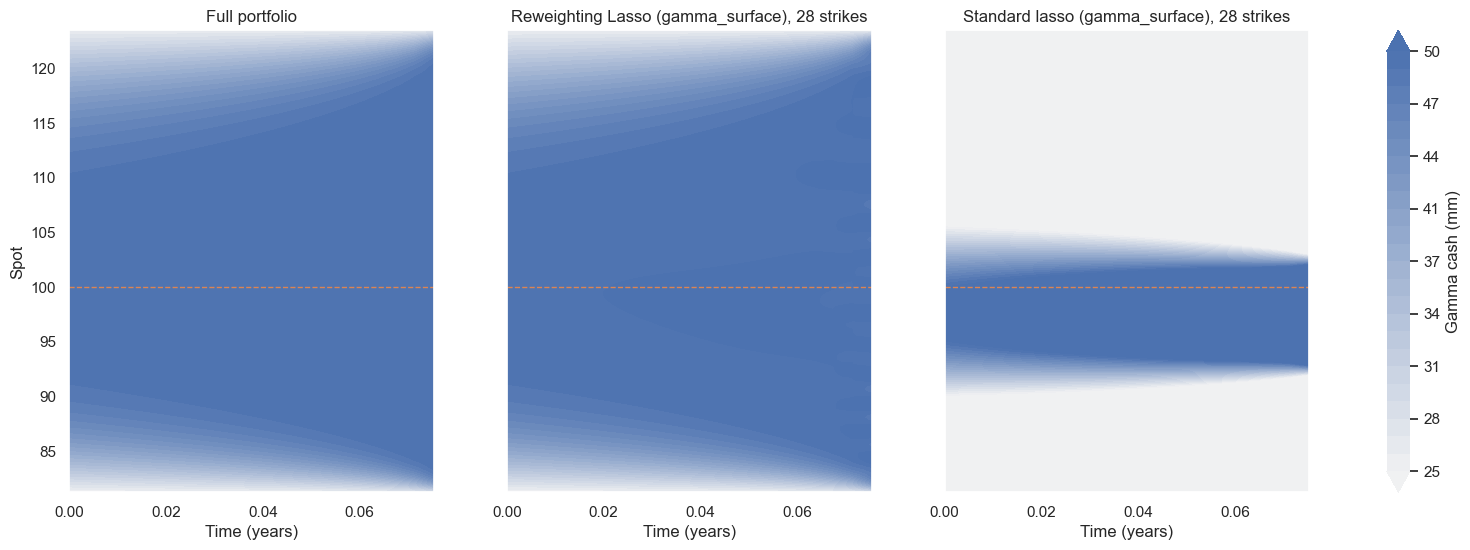

In [13]:
# Features: gamma cash of each option position on the Gamma surface (spot x time); target: gamma cash of the full portfolio.
# Every grid point has the same weight.
X_gamma_surface = pd.DataFrame(gamma_cash_by_option.reshape(-1, n_options), columns=option_names)
y_gamma_surface = X_gamma_surface.sum(axis=1)

gamma_surface_lasso = constrained_lasso(X_gamma_surface, y_gamma_surface, risk_positions, n_selected_options, **risk_constraints)
reduced_gamma_surface_portfolio = reduced_positions(gamma_surface_lasso)
gamma_surface_standard = standard_lasso(X_gamma_surface, y_gamma_surface, risk_positions, n_selected_options, **risk_constraints)
reduced_gamma_surface_standard_portfolio = reduced_positions(gamma_surface_standard)
for name, fit, reduced in (("Reweighting Lasso", gamma_surface_lasso, reduced_gamma_surface_portfolio), ("Standard lasso", gamma_surface_standard, reduced_gamma_surface_standard_portfolio)):
    print(f"{name}: {len(fit.weights)} of {n_options} options, gamma_surface R2 = {fit.r2:.4f}, "
          f"hedged P&L R2 = {pnl_r2(reduced):.4f}")
display(reduced_gamma_surface_portfolio)
display(gamma_surface_lasso.risk_check)
display(reduced_gamma_surface_standard_portfolio)
display(gamma_surface_standard.risk_check)

# Gamma surface of the full vs reduced portfolio on the full portfolio's colour scale (reduced spikes near expiry saturate)
levels = np.linspace(gamma_cash_mm.min(), gamma_cash_mm.max(), 25)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
for ax, grid, title in zip(axes,
                           (gamma_cash_mm, gamma_surface_cash_mm(reduced_gamma_surface_portfolio), gamma_surface_cash_mm(reduced_gamma_surface_standard_portfolio)),
                           ("Full portfolio", f"Reweighting Lasso (gamma_surface), {len(gamma_surface_lasso.weights)} strikes",
                            f"Standard lasso (gamma_surface), {len(gamma_surface_standard.weights)} strikes")):
    filled = ax.contourf(time_grid, spot_grid, grid, levels=levels, cmap=theme_cmap, extend="both")
    ax.axhline(S0, color=sns.color_palette()[1], linewidth=1, linestyle="--")
    ax.grid(False)
    ax.set_xlabel("Time (years)")
    ax.set_title(title)
axes[0].set_ylabel("Spot")
cbar = fig.colorbar(filled, ax=axes, format="%.0f")
cbar.set_label("Gamma cash (mm)")
cbar.outline.set_visible(False)
plt.show()

# Comparison of the reductions on the common hedged P&L yardstick
reductions = {
    ("P&L", "Reweighting Lasso"): (pnl_lasso, reduced_pnl_portfolio),
    ("P&L", "Standard lasso"): (pnl_standard, reduced_pnl_standard_portfolio),
    ("terminal payoff", "Reweighting Lasso"): (payoff_lasso, reduced_payoff_portfolio),
    ("terminal payoff", "Standard lasso"): (payoff_standard, reduced_payoff_standard_portfolio),
    ("gamma_at_inception", "Reweighting Lasso"): (gamma_at_inception_lasso, reduced_gamma_at_inception_portfolio),
    ("gamma_at_inception", "Standard lasso"): (gamma_at_inception_standard, reduced_gamma_at_inception_standard_portfolio),
    ("gamma_surface", "Reweighting Lasso"): (gamma_surface_lasso, reduced_gamma_surface_portfolio),
    ("gamma_surface", "Standard lasso"): (gamma_surface_standard, reduced_gamma_surface_standard_portfolio),
}

### Comparison

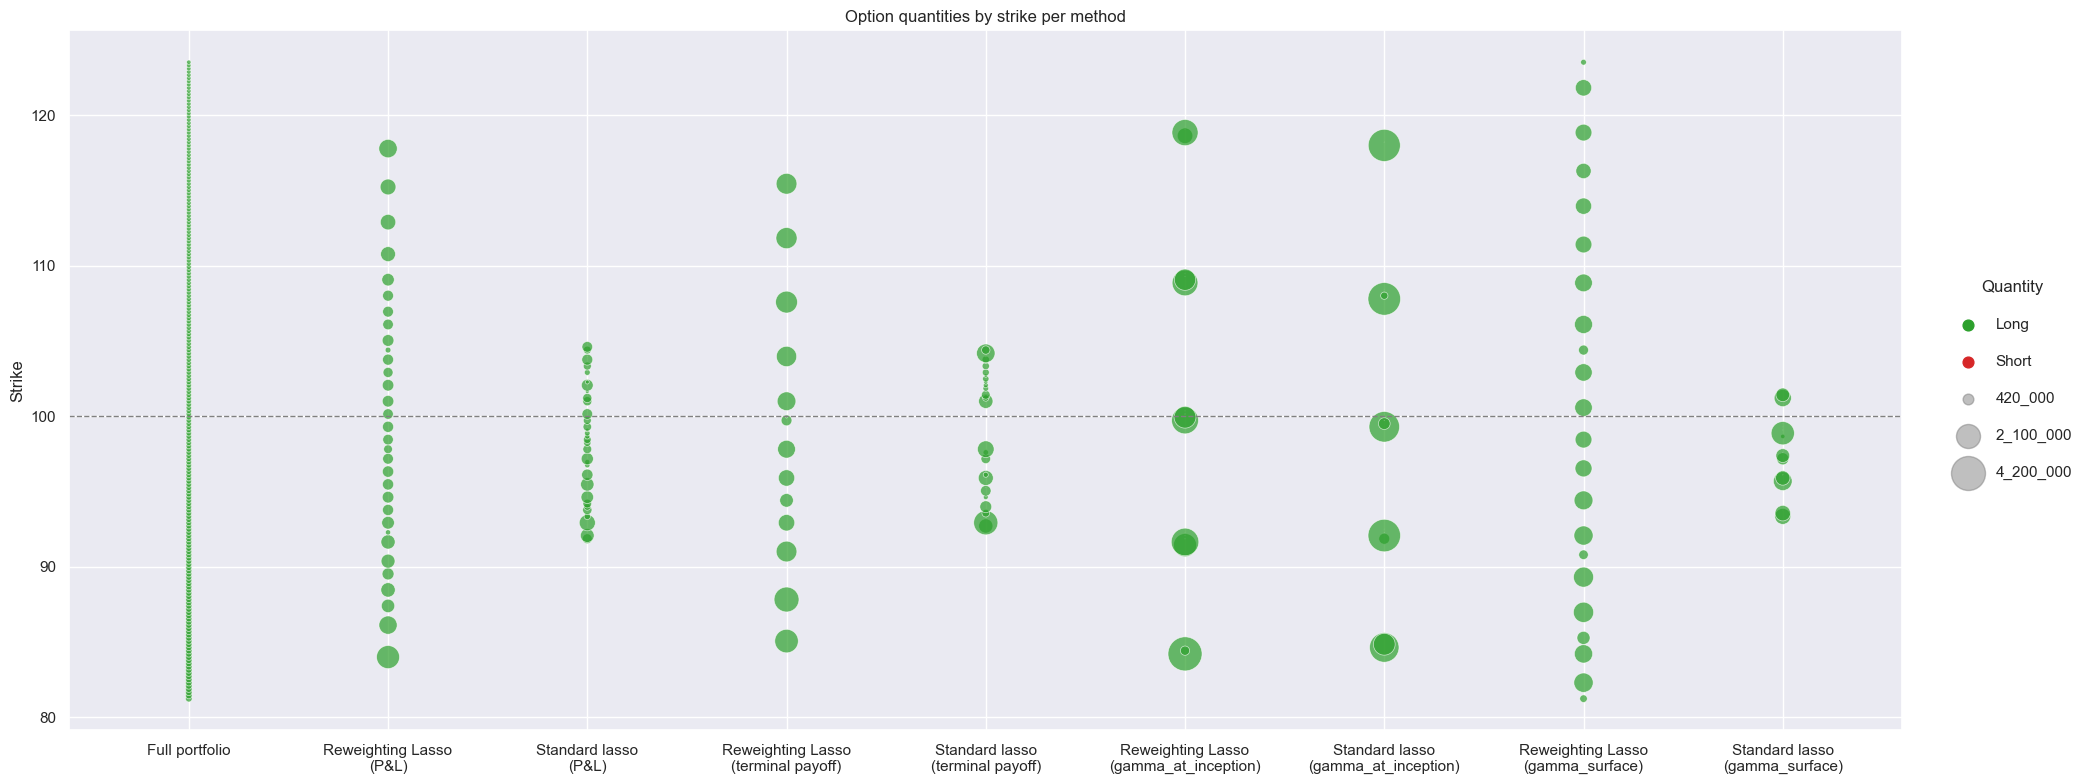

n_strikes  own_objective_r2  \
objective          algorithm                                        
full portfolio     -                        200                 1   
P&L                Reweighting Lasso         37            0.9998   
                   Standard lasso            38            0.9152   
terminal payoff    Reweighting Lasso         17            0.9997   
                   Standard lasso            37             0.966   
gamma_at_inception Reweighting Lasso         37            0.9999   
                   Standard lasso            26            0.9985   
gamma_surface      Reweighting Lasso         28            0.9991   
                   Standard lasso            28            -29.63   

                                      hedged_pnl_r2  hedged_pnl_std  \
objective          algorithm                                          
full portfolio     -                              1       2_499_659   
P&L                Reweighting Lasso         0.9998       2_499_766   
                   Standard lasso            0.9152       2_607_907   
terminal payoff    Reweighting Lasso         0.9958       2_506_847   
                   Standard lasso             0.923       2_599_726   
gamma_at_inception Reweighting Lasso         0.8743       2_636_857   
                   Standard lasso            0.8993       2_607_547   
gamma_surface      Reweighting Lasso         0.9984       2_499_529   
                   Standard lasso            0.8065       2_737_472   

                                      tracking_error_std  
objective          algorithm                              
full portfolio     -                                   0  
P&L                Reweighting Lasso              31_822  
                   Standard lasso                727_831  
terminal payoff    Reweighting Lasso             161_582  
                   Standard lasso                693_361  
gamma_at_inception Reweighting Lasso             886_115  
                   Standard lasso                793_089  
gamma_surface      Reweighting Lasso              99_300  
                   Standard lasso              1_099_346

full portfolio               P&L                  terminal payoff  \
                        - Reweighting Lasso Standard lasso Reweighting Lasso   
delta              92_152            43_467       -411_169            -208.7   
gamma_cash     50_000_000              -143         -32.94             -32.5   
theta            -396_825             1.135         0.2614             0.258   
vega              793_651             -2.27        -0.5229           -0.5159   
slide_-5%       6_464_369             3_995        263_672             8_691   
slide_-10%     26_731_830            -78.03         -17.21            -12.08   

                          gamma_at_inception                    gamma_surface  \
           Standard lasso  Reweighting Lasso Standard lasso Reweighting Lasso   
delta               3_041           -407_879     -1_697_384           182_812   
gamma_cash         -70.03             -375.8         -370.2            -132.9   
theta              0.5558              2.983          2.938             1.055   
vega               -1.112             -5.965         -5.876            -2.109   
slide_-5%         231_082              311.2          4_616             64.52   
slide_-10%         -43.16             -199.8         -194.9             371.9   

                           
           Standard lasso  
delta          -1_178_245  
gamma_cash         -98.37  
theta              0.7807  
vega               -1.561  
slide_-5%         353_666  
slide_-10%         -52.53

Constraints satisfied: {'P&L / Reweighting Lasso': True, 'P&L / Standard lasso': True, 'terminal payoff / Reweighting Lasso': True, 'terminal payoff / Standard lasso': True, 'gamma_at_inception / Reweighting Lasso': True, 'gamma_at_inception / Standard lasso': True, 'gamma_surface / Reweighting Lasso': True, 'gamma_surface / Standard lasso': True}


In [14]:
method_quantities["Reweighting Lasso (gamma_surface)"] = reduced_gamma_surface_portfolio.set_index("strike")["reduced_quantity"]
method_quantities["Standard lasso (gamma_surface)"] = reduced_gamma_surface_standard_portfolio.set_index("strike")["reduced_quantity"]
plot_strike_map(method_quantities)


comparison = pd.DataFrame(
    {
        "n_strikes": [len(reduced) for _, reduced in reductions.values()],
        "own_objective_r2": [fit.r2 for fit, _ in reductions.values()],
        "hedged_pnl_r2": [pnl_r2(reduced) for _, reduced in reductions.values()],
        "hedged_pnl_std": [reduced_pnl(reduced).std() for _, reduced in reductions.values()],
        "tracking_error_std": [(y - reduced_pnl(reduced)).std() for _, reduced in reductions.values()],
    },
    index=pd.MultiIndex.from_tuples(reductions.keys(), names=["objective", "algorithm"]),
)
# Reference row: the full portfolio (tracking error is zero by construction)
comparison.loc[("full portfolio", "-"), :] = [n_options, 1.0, 1.0, y.std(), 0.0]
comparison = comparison.astype({"n_strikes": int}).iloc[[-1, *range(len(reductions))]]
display(comparison)

# t0 risk check of every reduction: (reduced - full portfolio) per metric, and whether all constraints hold
# (enforced by both lassos)
risk_check = pd.DataFrame({key: fit.risk_check["diff"] for key, (fit, _) in reductions.items()})
risk_check.insert(0, ("full portfolio", "-"), full_risk)
display(risk_check)
print("Constraints satisfied:", {f"{objective} / {algorithm}": bool(fit.risk_check["ok"].dropna().all())
                                 for (objective, algorithm), (fit, _) in reductions.items()})

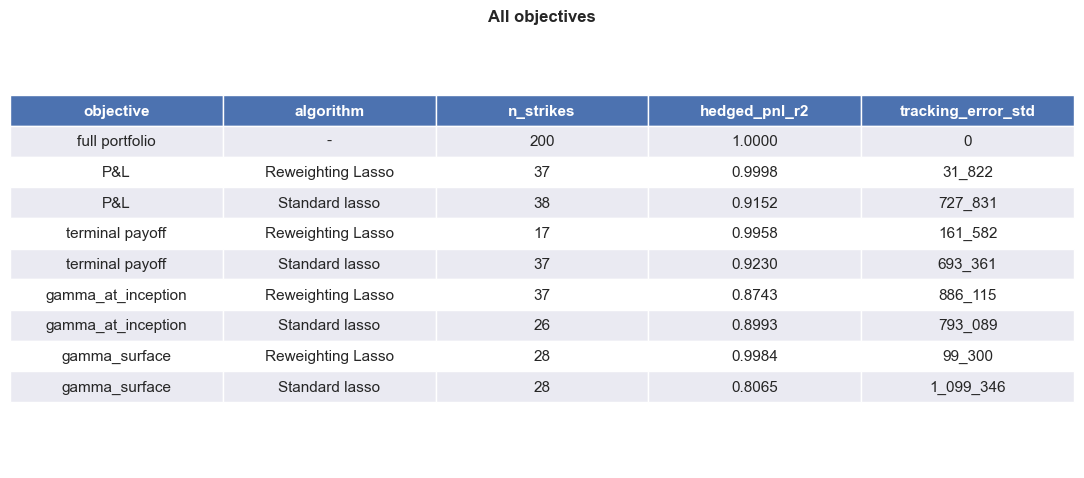

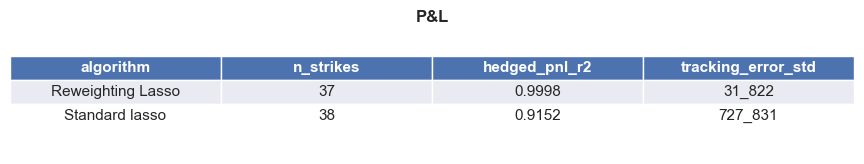

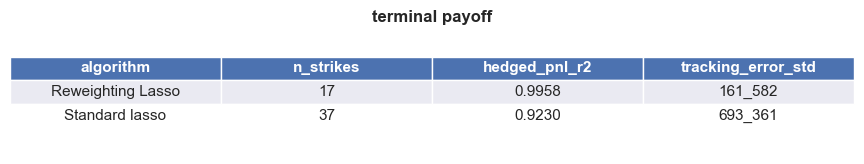

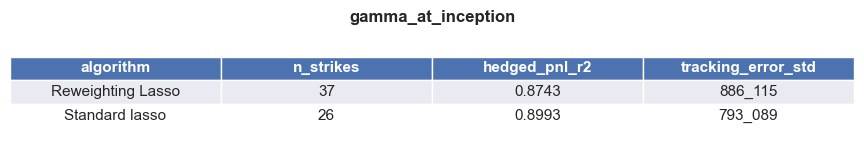

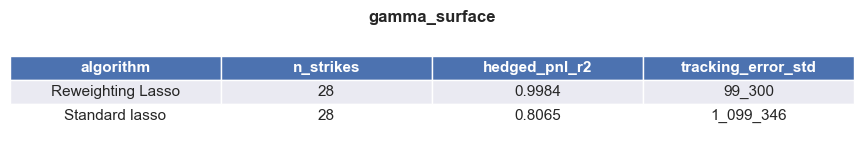

In [15]:
# Summary tables of the comparison, drawn with matplotlib: the full one, then one per objective
summary_table = comparison[["n_strikes", "hedged_pnl_r2", "tracking_error_std"]].reset_index()
plot_table(summary_table, "All objectives")
for objective, objective_table in summary_table[summary_table["objective"] != "full portfolio"].groupby("objective", sort=False):
    plot_table(objective_table.drop(columns="objective"), objective)

### Sample use: terminal payoff Reweighting Lasso

put_90.36     4_461_396
put_95.25     1_914_774
put_98.22     1_372_575
put_99.71       139_875
call_101.41   1_716_390
call_103.75     603_678
call_106.72   1_692_821
call_110.97   2_269_140
dtype: float64

,portfolio,reduced,diff,ok
delta,92_152,94_251,2_099,NaN
gamma_cash,50_000_000,49_999_987,-12.51,True
theta,-396_825,-396_825,0.09932,True
vega,793_651,793_651,-0.1986,True
slide_-5%,6_464_369,6_517_788,53_419,True
slide_-10%,26_731_830,26_731_818,-12.79,True
bid_offer,-31_226_067,-8_235_754,22_990_313,True


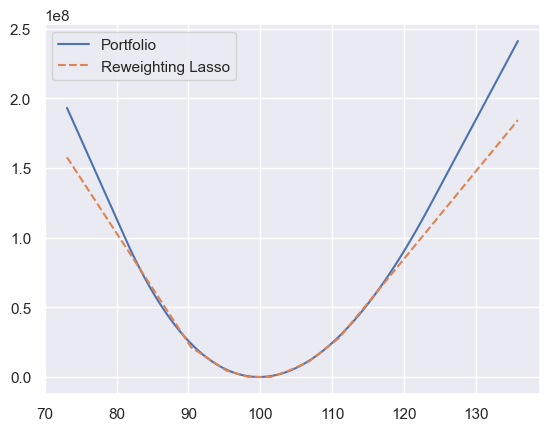

In [16]:
# Reduce the notebook portfolio to 8 options matching its terminal payoff under the t0 risk constraints, losing at
# most 80% of the full portfolio bid-offer P&L
portfolio_weight = portfolio.set_index("name")["quantity"]
option_terminal_payoff = pd.DataFrame(intrinsic_values(terminal_spots), index=terminal_spots, columns=option_names)
risk_t0 = risk_positions.div(quantities, axis=0)                          # unit risk per option

option_bid_offer = pd.Series(index=option_terminal_payoff.columns, data=0.0)
option_bid_offer.loc[:] = [(float(x.split('_')[1]) - 100)**2 * -0.01 for x in option_bid_offer.index]
result = quick_terminal_payoff_lasso(portfolio_weight, option_terminal_payoff, risk_t0,
                                     risk_floor=["gamma_cash", "theta", "slide_-5%", "slide_-10%"],
                                     risk_tolerance={"vega": 0.05}, max_position=8,
                                     option_bid_offer=option_bid_offer, pnl_haircut=0.8)
display(result.weights, result.risk_check)

plt.plot(terminal_spot, intrinsic @ quantities, label="Portfolio")
plt.plot(terminal_spot, pd.DataFrame(intrinsic, columns=option_names)[result.weights.index] @ result.weights, "--", label="Reweighting Lasso")
plt.legend()
plt.show()